# Preprocessing Pipeline — C-MAPSS FD001

**Thesis**: Self-Updating Predictive Maintenance with Closed-Loop Drift Recovery
**Author**: Dogancan Torun
**Source EDA**: `notebooks/01_eda.ipynb` and `docs/eda_findings.md`

## Goal

Convert raw C-MAPSS data into LSTM-ready tensors, following the
data-driven decisions made in the EDA notebook:

1. Drop 8 constant features (std < 10^-3)
2. Derive RUL per engine
3. Cap RUL at 125 cycles
4. Engine-based train/val split (80/20, no temporal leakage)
5. Min-Max normalize features (fit on train, transform both)
6. Build sliding-window sequences of length 30 for LSTM input

## Output

- `data/processed/X_train.npy`, `y_train.npy`
- `data/processed/X_val.npy`, `y_val.npy`
- `data/processed/scaler.pkl`

All artifacts are version-controlled via DVC and pushed to MinIO.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Add project root to Python path so we can import src.preprocessing
PROJECT_ROOT = Path("/root/thesis-infra")
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    load_cmapss,
    drop_constant_features,
    compute_rul,
    piecewise_rul,
    engine_based_split,
    fit_scaler,
    apply_scaler,
    create_sequences,
    get_feature_columns,
    CONSTANT_FEATURES,
    RUL_CAP,
    DEFAULT_WINDOW,
)

# Plot defaults
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")

print("Preprocessing module loaded")
print(f"Constant features dropped: {len(CONSTANT_FEATURES)}")
print(f"RUL cap: {RUL_CAP}")
print(f"Window size: {DEFAULT_WINDOW}")

Preprocessing module loaded
Constant features dropped: 8
RUL cap: 125
Window size: 30


In [2]:
# Load FD001
raw_path = PROJECT_ROOT / "data/raw/cmapss/train_FD001.txt"
df_raw = load_cmapss(raw_path)
print(f"Raw shape:        {df_raw.shape}")

# Drop constant features
df = drop_constant_features(df_raw)
print(f"After dropping {len(CONSTANT_FEATURES)} constants: {df.shape}")
print(f"Dropped features: {CONSTANT_FEATURES}")

Raw shape:        (20631, 26)
After dropping 8 constants: (20631, 18)
Dropped features: ['op_setting_2', 'op_setting_3', 'sensor_01', 'sensor_05', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


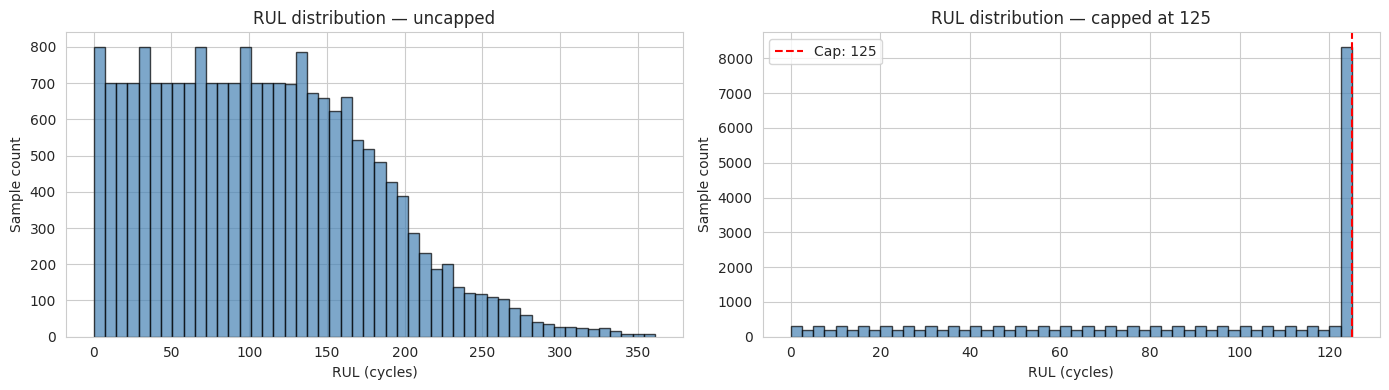


Uncapped RUL range: 0 to 361
Capped RUL range:   0 to 125

Samples with RUL == 125 (capped): 8,131 (39.4% of data)


In [3]:
# Compute RUL
df = compute_rul(df)

# Cap at 125
df = piecewise_rul(df, cap=RUL_CAP)

# Visualize the effect of capping
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before capping
df_raw_rul = compute_rul(drop_constant_features(df_raw))
axes[0].hist(df_raw_rul['RUL'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title("RUL distribution — uncapped")
axes[0].set_xlabel("RUL (cycles)")
axes[0].set_ylabel("Sample count")

# After capping
axes[1].hist(df['RUL'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title(f"RUL distribution — capped at {RUL_CAP}")
axes[1].set_xlabel("RUL (cycles)")
axes[1].set_ylabel("Sample count")
axes[1].axvline(RUL_CAP, color='red', linestyle='--', label=f'Cap: {RUL_CAP}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nUncapped RUL range: {df_raw_rul['RUL'].min()} to {df_raw_rul['RUL'].max()}")
print(f"Capped RUL range:   {df['RUL'].min()} to {df['RUL'].max()}")
print(f"\nSamples with RUL == {RUL_CAP} (capped): {(df['RUL'] == RUL_CAP).sum():,} "
      f"({(df['RUL'] == RUL_CAP).sum() / len(df) * 100:.1f}% of data)")

In [4]:
# Split BEFORE normalization (so scaler is fit on train only)
df_train_raw, df_val_raw = engine_based_split(df, val_fraction=0.2, random_seed=42)

train_engines = sorted(df_train_raw['unit_number'].unique())
val_engines = sorted(df_val_raw['unit_number'].unique())

print(f"Train engines ({len(train_engines)}): {train_engines[:10]}... (showing first 10)")
print(f"Val engines   ({len(val_engines)}):  {val_engines}")
print()
print(f"Train rows: {len(df_train_raw):,}")
print(f"Val rows:   {len(df_val_raw):,}")
print()

# Sanity check: no engine appears in both
overlap = set(train_engines) & set(val_engines)
assert len(overlap) == 0, f"Data leakage! Engines in both splits: {overlap}"
print(f"✓ No engine overlap between train and val (data leakage prevented)")

Train engines (80): [1, 2, 4, 6, 7, 8, 9, 10, 11, 12]... (showing first 10)
Val engines   (20):  [3, 5, 19, 22, 25, 26, 28, 34, 43, 51, 52, 53, 57, 60, 62, 72, 82, 93, 98, 100]

Train rows: 16,779
Val rows:   3,852

✓ No engine overlap between train and val (data leakage prevented)


In [5]:
# Fit scaler on training data ONLY
scaler = fit_scaler(df_train_raw)

# Apply to both train and val
df_train = apply_scaler(df_train_raw, scaler)
df_val = apply_scaler(df_val_raw, scaler)

# Verify normalization worked: features should now be in [0, 1]
feature_cols = get_feature_columns(df_train)
print(f"Feature columns ({len(feature_cols)}):")
print(f"  {feature_cols}\n")

print("Train feature ranges after normalization:")
print(df_train[feature_cols].describe().loc[['min', 'max']].T)

Feature columns (16):
  ['op_setting_1', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Train feature ranges after normalization:
              min  max
op_setting_1  0.0  1.0
sensor_02     0.0  1.0
sensor_03     0.0  1.0
sensor_04     0.0  1.0
sensor_06     0.0  1.0
sensor_07     0.0  1.0
sensor_08     0.0  1.0
sensor_09     0.0  1.0
sensor_11     0.0  1.0
sensor_12     0.0  1.0
sensor_13     0.0  1.0
sensor_14     0.0  1.0
sensor_15     0.0  1.0
sensor_17     0.0  1.0
sensor_20     0.0  1.0
sensor_21     0.0  1.0


In [6]:
# Build sliding-window sequences for LSTM
X_train, y_train = create_sequences(df_train, window=DEFAULT_WINDOW, feature_cols=feature_cols)
X_val, y_val = create_sequences(df_val, window=DEFAULT_WINDOW, feature_cols=feature_cols)

print(f"LSTM input shape: (n_sequences, window, n_features)")
print()
print(f"X_train: {X_train.shape}  dtype={X_train.dtype}")
print(f"y_train: {y_train.shape}  dtype={y_train.dtype}")
print(f"X_val:   {X_val.shape}  dtype={X_val.dtype}")
print(f"y_val:   {y_val.shape}  dtype={y_val.dtype}")
print()

# Verify shapes
assert X_train.ndim == 3, "X_train should be 3D"
assert X_train.shape[1] == DEFAULT_WINDOW, "Window size mismatch"
assert X_train.shape[2] == len(feature_cols), "Feature count mismatch"
print(f"✓ Shapes valid for LSTM input")
print(f"  Window size:  {X_train.shape[1]} cycles")
print(f"  Features:     {X_train.shape[2]}")
print(f"  Train samples: {X_train.shape[0]:,}")
print(f"  Val samples:   {X_val.shape[0]:,}")

LSTM input shape: (n_sequences, window, n_features)

X_train: (14459, 30, 16)  dtype=float32
y_train: (14459,)  dtype=float32
X_val:   (3272, 30, 16)  dtype=float32
y_val:   (3272,)  dtype=float32

✓ Shapes valid for LSTM input
  Window size:  30 cycles
  Features:     16
  Train samples: 14,459
  Val samples:   3,272


In [8]:
# Save to data/processed/ — these go to DVC, not Git
output_dir = PROJECT_ROOT / "data/processed"
output_dir.mkdir(parents=True, exist_ok=True)

# Save numpy arrays
np.save(output_dir / "X_train.npy", X_train)
np.save(output_dir / "y_train.npy", y_train)
np.save(output_dir / "X_val.npy", X_val)
np.save(output_dir / "y_val.npy", y_val)

# Save scaler (for inference time — FastAPI and Evidently will use this)
joblib.dump(scaler, output_dir / "scaler.pkl")

# Save feature column order (so FastAPI sends features in the right order)
import json
metadata = {
    'feature_cols': feature_cols,
    'window': DEFAULT_WINDOW,
    'rul_cap': RUL_CAP,
    'constant_features_dropped': CONSTANT_FEATURES,
    'n_train_engines': len(train_engines),
    'n_val_engines': len(val_engines),
    'train_samples': int(X_train.shape[0]),
    'val_samples': int(X_val.shape[0]),
}

with open(output_dir / "metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

# Verify
print("Saved artifacts:")
for f in sorted(output_dir.glob("*")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:25s}  {size_kb:8.1f} KB")

Saved artifacts:
  X_train.npy                 27110.8 KB
  X_val.npy                    6135.1 KB
  metadata.json                   0.6 KB
  scaler.pkl                      1.3 KB
  y_train.npy                    56.6 KB
  y_val.npy                      12.9 KB
